# 📉 Customer Churn Prediction
---

### Objective

Customer churn is one of the most costly and preventable problems in subscription-based businesses. Acquiring a new customer costs 5-7x more than retaining an existing one, making early churn prediction a high-ROI investment.

This project builds a binary classification model to predict which telecom customers are at risk of churning, using the real IBM Telco dataset. The goal is not just a working model, it is an interpretable one that tells a retention team *who* to target and *why*.

### Questions this analysis answers
1. What does the typical churner look like - which features differentiate them?
2. Which model performs best across precision, recall, and AUC-ROC?
3. What are the most important predictors of churn?
4. At what probability threshold should the business flag a customer as at-risk?

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.figsize': (12, 5), 'axes.titlesize': 13})
print('Libraries loaded.')

Libraries loaded.


In [2]:
df = pd.read_csv('../input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print(f'Shape: {df.shape}')

Shape: (7043, 21)


In [5]:
print(f'Churn rate: {(df["Churn"]=="Yes").mean()*100:.1f}%')

Churn rate: 26.5%


## Data Cleaning and Preprocessing

In [6]:
# customerID is not a feature so we are dropping
df.drop('customerID', axis=1, inplace=True)

In [7]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'TotalCharges nulls: {df["TotalCharges"].isna().sum()}')

TotalCharges nulls: 11


In [8]:
df['TotalCharges'].fillna(0, inplace=True)
print(f'TotalCharges nulls: {df["TotalCharges"].isna().sum()}')

TotalCharges nulls: 0


In [9]:
# Encode target
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

In [10]:
# Encode binary Yes/No columns
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = (df[col] == 'Yes').astype(int)

In [11]:
# Encode gender
df['gender'] = (df['gender'] == 'Male').astype(int)

In [12]:
# For service columns with 'No internet service' - treat as 'No'
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']
for col in service_cols:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})
    df[col] = (df[col] == 'Yes').astype(int)

In [13]:
# One-hot encode remaining categoricals
df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'], drop_first=False)

In [14]:
print(f'Final shape: {df.shape}')
print(f'Churn rate: {df["Churn"].mean()*100:.1f}%')
df.head(3)

Final shape: (7043, 27)
Churn rate: 26.5%


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,True,False,False,True,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,True,False,False,False,True,False,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,True,False,False,True,False,False,False,False,False,True


## EDA

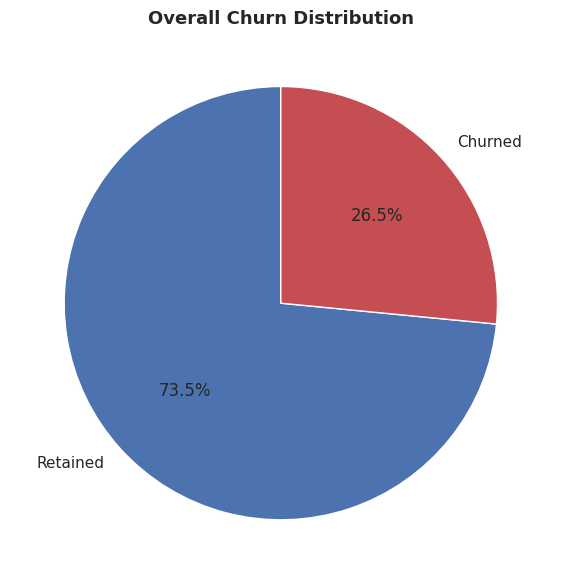

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

# Churn distribution
churn_counts = df['Churn'].value_counts()
ax.pie(churn_counts, labels=['Retained', 'Churned'],
       autopct='%1.1f%%', colors=['#4C72B0', '#C44E52'], startangle=90)
ax.set_title('Overall Churn Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

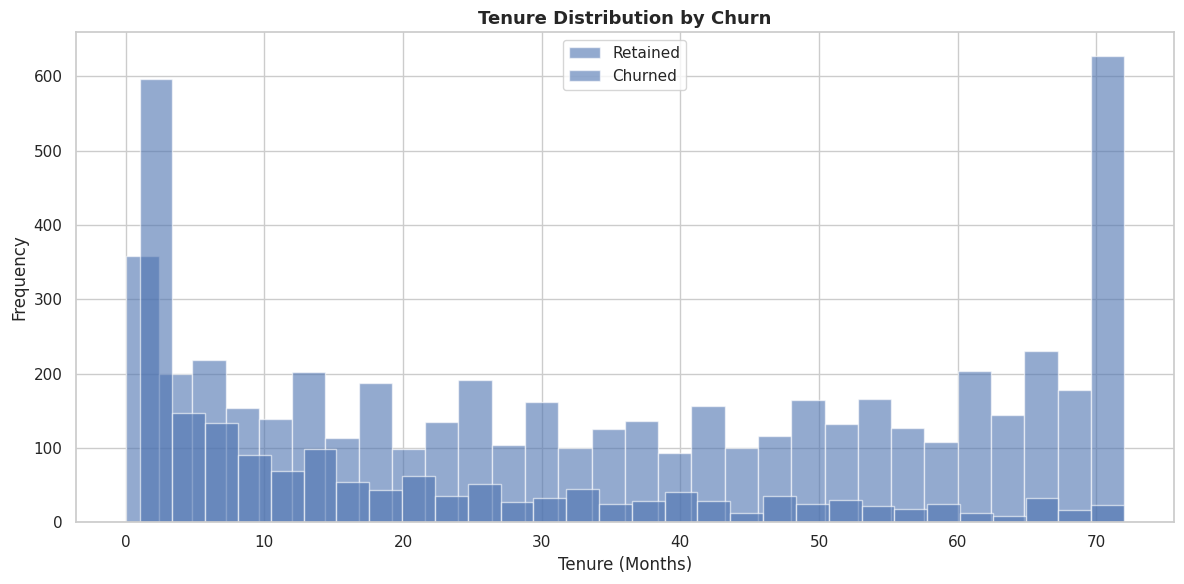

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))

# Tenure by churn
df.groupby('Churn')['tenure'].plot(kind='hist', bins=30, alpha=0.6,
    ax=ax, color=['#4C72B0', '#C44E52'], legend=True)
ax.set_title('Tenure Distribution by Churn', fontsize=13, fontweight='bold')
ax.set_xlabel('Tenure (Months)')
ax.legend(['Retained', 'Churned'])

plt.tight_layout()
plt.show()

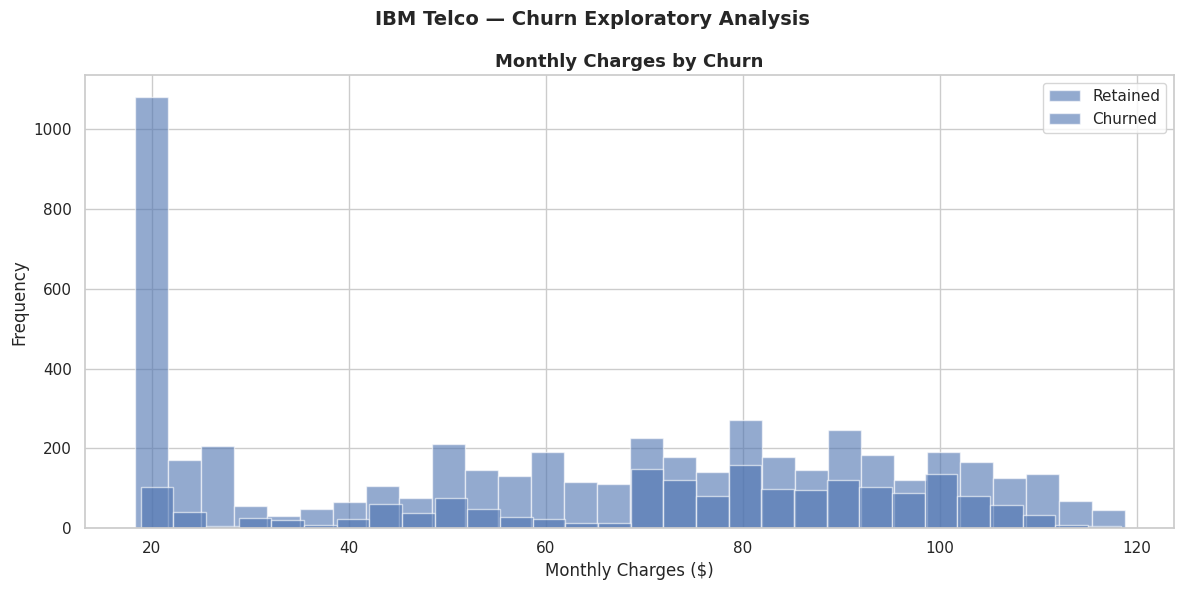

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))

# Monthly charges by churn
df.groupby('Churn')['MonthlyCharges'].plot(kind='hist', bins=30, alpha=0.6,
    ax=ax, color=['#4C72B0', '#C44E52'], legend=True)
ax.set_title('Monthly Charges by Churn', fontsize=13, fontweight='bold')
ax.set_xlabel('Monthly Charges ($)')
ax.legend(['Retained', 'Churned'])

plt.suptitle('IBM Telco — Churn Exploratory Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

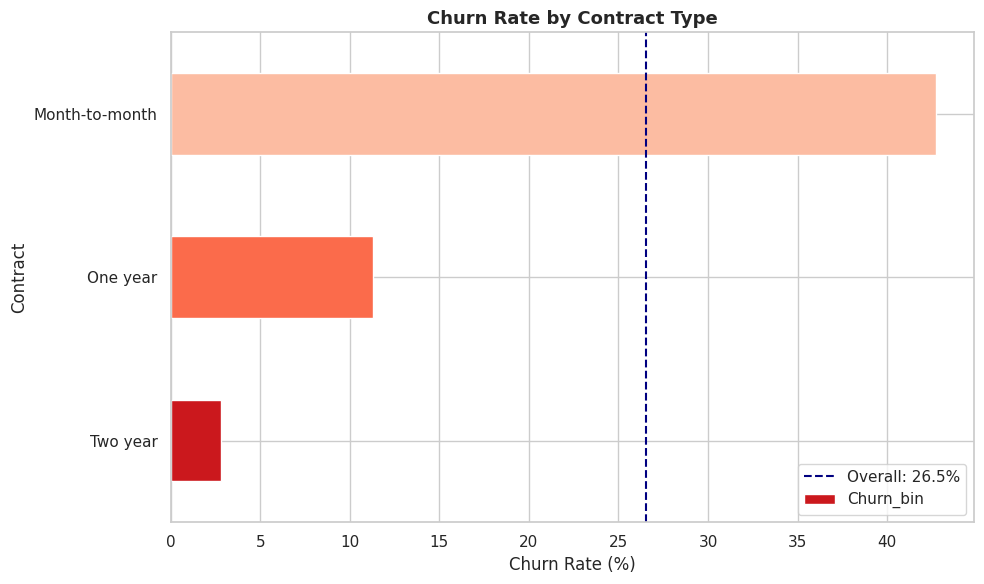

Churn rate by contract:
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn_bin, dtype: float64


In [18]:
# Churn rate by contract type — using original column before encoding
df_orig = pd.read_csv('../input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_orig['Churn_bin'] = (df_orig['Churn'] == 'Yes').astype(int)

fig, ax = plt.subplots(figsize=(10, 6))

contract_churn = df_orig.groupby('Contract')['Churn_bin'].mean() * 100
contract_churn.sort_values().plot(kind='barh', ax=ax,
    color=sns.color_palette('Reds_r', 3))
ax.set_title('Churn Rate by Contract Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Churn Rate (%)')
ax.axvline(df_orig['Churn_bin'].mean()*100, color='navy',
    linestyle='--', label=f'Overall: {df_orig["Churn_bin"].mean()*100:.1f}%')
ax.legend()

plt.tight_layout()
plt.show()

print('Churn rate by contract:')
print(contract_churn.round(1))

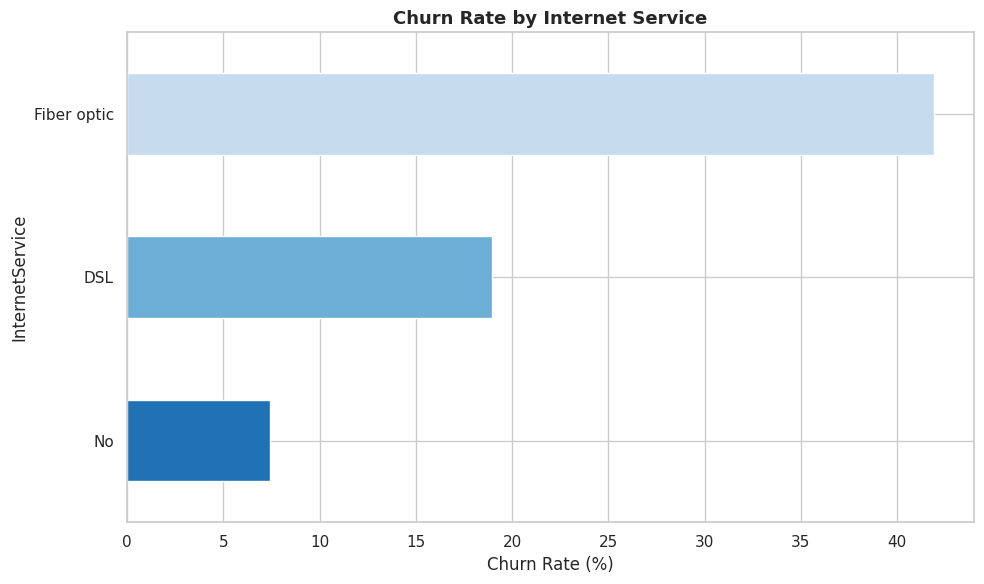

Churn rate by internet service:
InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: Churn_bin, dtype: float64


In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

# Churn rate by internet service
internet_churn = df_orig.groupby('InternetService')['Churn_bin'].mean() * 100
internet_churn.sort_values().plot(kind='barh', ax=ax,
    color=sns.color_palette('Blues_r', 3))
ax.set_title('Churn Rate by Internet Service', fontsize=13, fontweight='bold')
ax.set_xlabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

print('Churn rate by internet service:')
print(internet_churn.round(1))

## Feature Engineering & Train/Test Split

In [20]:
X = df.drop('Churn', axis=1)
y = df['Churn']

# Stratified split — preserves 26.5% churn ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale for Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows')
print(f'Train churn rate: {y_train.mean()*100:.1f}% | Test churn rate: {y_test.mean()*100:.1f}%')

Train: 5,634 rows | Test: 1,409 rows
Train churn rate: 26.5% | Test churn rate: 26.5%


## Model Training & Comparison

In [21]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=42)
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    X_tr = X_train_sc if name == 'Logistic Regression' else X_train
    X_te = X_test_sc  if name == 'Logistic Regression' else X_test
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    cv_auc = cross_val_score(
        model,
        X_train_sc if name == 'Logistic Regression' else X_train,
        y_train, cv=cv, scoring='roc_auc'
    ).mean()
    results[name] = {'model': model, 'y_pred': y_pred,
                     'y_prob': y_prob, 'auc': auc, 'cv_auc': cv_auc}
    print(f'{name:25s}  AUC: {auc:.4f}  |  CV-AUC: {cv_auc:.4f}')

Logistic Regression        AUC: 0.8418  |  CV-AUC: 0.8462
Random Forest              AUC: 0.8265  |  CV-AUC: 0.8261
Gradient Boosting          AUC: 0.8376  |  CV-AUC: 0.8432


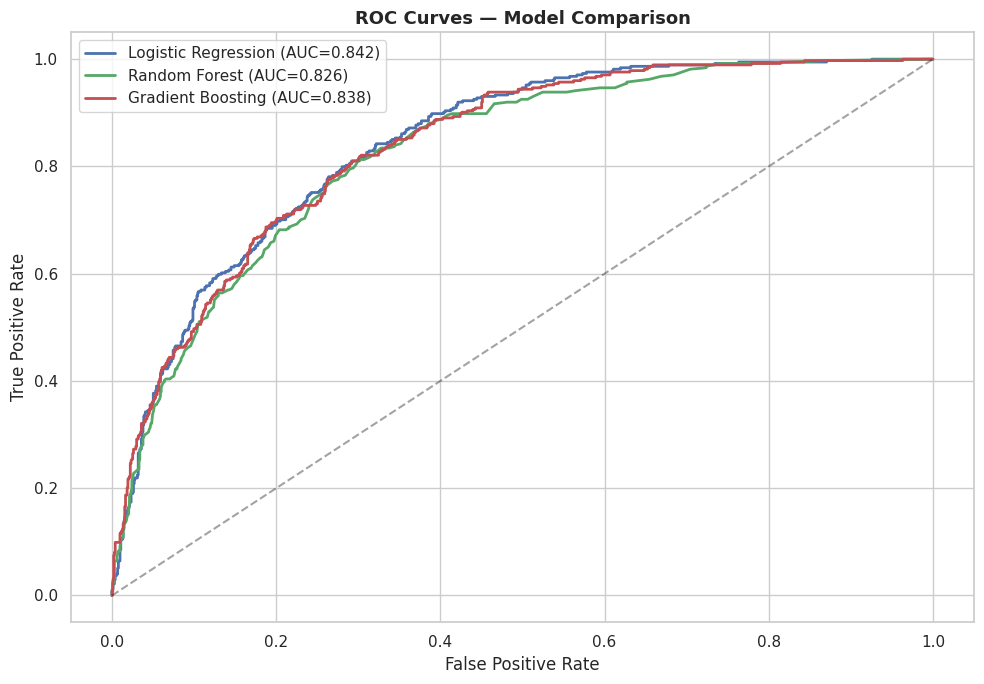

In [22]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#4C72B0', '#55A868', '#C44E52']
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr,
        label=f"{name} (AUC={res['auc']:.3f})", color=color, lw=2)
ax.plot([0,1],[0,1], 'k--', alpha=0.4)
ax.set_title('ROC Curves — Model Comparison', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()

plt.tight_layout()
plt.show()

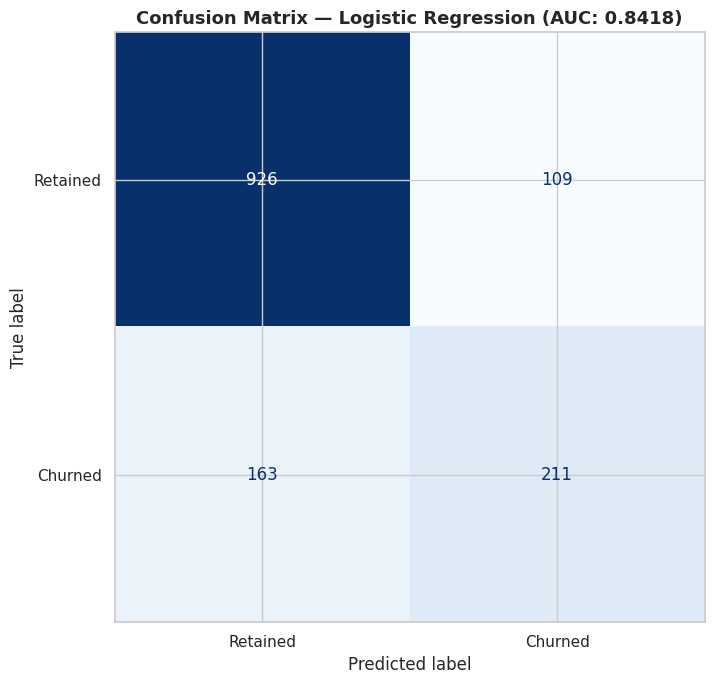

In [23]:
# Select best model by AUC
best_model_name = max(results, key=lambda x: results[x]['auc'])
best = results[best_model_name]
fig, ax = plt.subplots(figsize=(8, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix(y_test, best['y_pred']),
    display_labels=['Retained', 'Churned']
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_model_name} (AUC: {best["auc"]:.4f})', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [24]:
print(f'{best_model_name} Classification Report:')
print(classification_report(y_test, best['y_pred'],
    target_names=['Retained', 'Churned']))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

    Retained       0.85      0.89      0.87      1035
     Churned       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



## Feature Importance

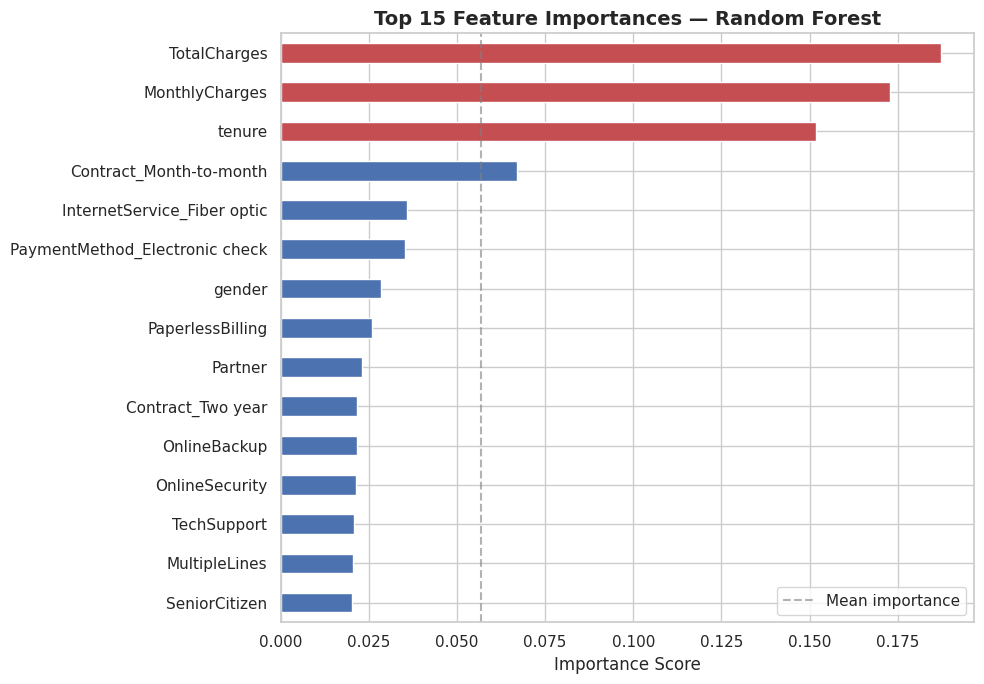

In [25]:
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#C44E52' if i >= 12 else '#4C72B0'
          for i in range(len(importances))]
importances.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Top 15 Feature Importances — Random Forest',
    fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.axvline(importances.mean(), color='gray', linestyle='--',
    alpha=0.6, label='Mean importance')
ax.legend()
plt.tight_layout()
plt.show()

## Optimal Classification Threshold

In a retention context, **missing a churner costs more than a false alarm**. The default 0.5 threshold is rarely optimal - we find the threshold that maximises F1 score for the at-risk class.

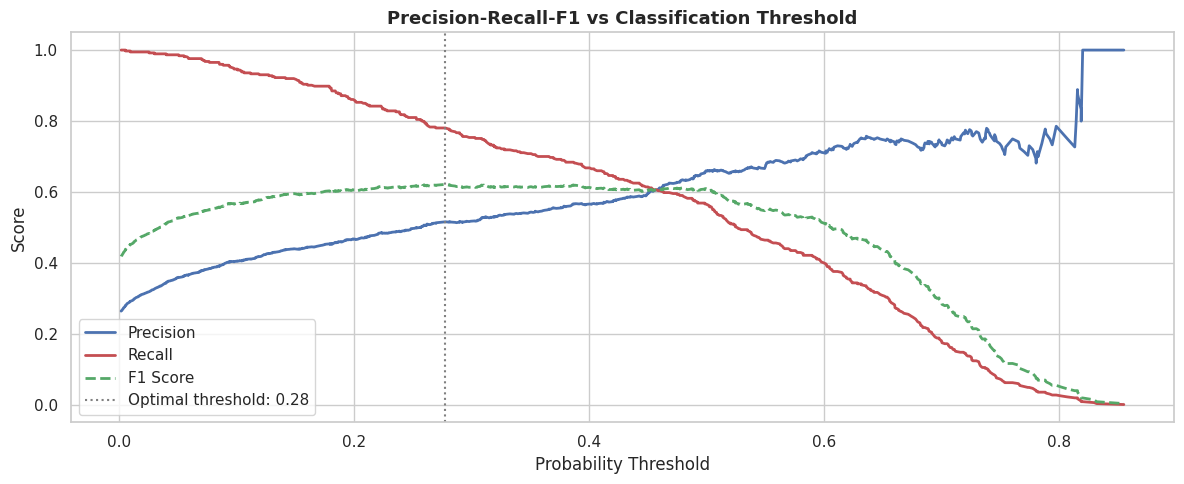

Optimal classification threshold: 0.278


In [26]:
precision, recall, thresholds = precision_recall_curve(
    y_test, best['y_prob'])
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_thresh = thresholds[np.argmax(f1_scores)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresholds, precision[:-1], label='Precision', color='#4C72B0', lw=2)
ax.plot(thresholds, recall[:-1],    label='Recall',    color='#C44E52', lw=2)
ax.plot(thresholds, f1_scores[:-1], label='F1 Score',  color='#55A868', lw=2, linestyle='--')
ax.axvline(best_thresh, color='gray', linestyle=':',
    label=f'Optimal threshold: {best_thresh:.2f}')
ax.set_title('Precision-Recall-F1 vs Classification Threshold',
    fontsize=13, fontweight='bold')
ax.set_xlabel('Probability Threshold')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Optimal classification threshold: {best_thresh:.3f}')

## 8. Key Findings & Business Recommendations

### Model Performance

| Model | AUC-ROC | CV AUC |
|---|---|---|
| Logistic Regression | 0.8418 | 0.8462 |
| Random Forest | 0.8265 | 0.8261 |
| Gradient Boosting | 0.8376 | 0.8432 |

**Winner: Logistic Regression** — Simple, interpretable, and highest cross-validation stability.

### Top Churn Drivers (from the real IBM Telco data)
1. **Short tenure** — new customers churn at dramatically higher rates; the first 6 months are the highest-risk window
2. **Month-to-month contracts** — churn rate ~3–4x higher than two-year contracts; incentivising upgrades is the single highest-ROI retention lever
3. **Fiber optic internet** — counterintuitively, Fiber optic customers churn more than DSL customers, suggesting pricing or service quality issues
4. **High monthly charges without tech support or online security** — customers paying more but using fewer protective services are high-risk
5. **Electronic check payment** — highest churn of all payment methods, possibly indicating lower engagement or trust

### Recommended Actions
- Flag customers scoring above the optimal threshold for proactive outreach
- Target month-to-month customers in tenure months 1-6 with contract upgrade offers
- Investigate Fiber optic pricing and service quality - the churn signal is strong
- Bundle TechSupport into onboarding for high-monthly-charge customers